# Cup & Handle — a quantitative teardown 🔬
### An objective swing-pivot detector · forward 5/10/20/40-day **excess** over the base rate · one-sample & HAC *t* vs a **same-tape label-shuffle placebo** · detector-strictness robustness · the SPY small-*n* mirage · a synthetic faithful-engine / power control

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Beats_buy--and--hold%3F: Busted](https://img.shields.io/badge/Beats_buy--and--hold%3F-Busted-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb). The cup-with-handle is the **most subjective** classic figure, so we fix one transparent mechanical definition and arbitrate it honestly. The headline lesson is a methodology lesson: a one-sample *t* against **zero** clears 2 at one horizon — and a **same-tape placebo busts it**, because the null isn't zero, it's the tape's own drift.

> ⚠️ **Data + survivorship note.** Fixed **30-name large-cap** basket incl. **SPY**, names still trading in 2026 — a *survivor* panel whose bias tilts post-breakout returns *up* (i.e. *for* the figure), and it still fails. Real data: yfinance daily auto-adjusted OHLC, 2005→2026, as-of **2026-05-31**. Offline core + synthetic control are deterministic. Methods in [`docs/references.md`](../docs/references.md), numbers in [`docs/results.md`](../docs/results.md).
>
> 💡 **The `💡 In plain words` notes** translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from cup_and_handle import data, strategy as st

ASOF = "2026-05-31"
HAVE_REAL = data.have_real()
if HAVE_REAL:
    PANEL = data.load_real()
    _a = pd.Timestamp(ASOF)
    for _f in PANEL:
        PANEL[_f] = PANEL[_f].loc[:_a]
else:
    PANEL = None
print("real cup-and-handle cache present:", HAVE_REAL,
      "| names:", (0 if PANEL is None else PANEL["close"].shape[1]),
      "| bars:", (0 if PANEL is None else len(PANEL["close"])))

# frozen headline numbers (mirror of docs/results.md)
R = {'asof': '2026-05-31', 'start': '2005-01-03', 'end': '2026-05-29', 'years': 21.4, 'n_names': 30, 'n_bars': 5385, 'n_breakouts': 443, 'n_spy': 8, 'fingerprint': 'b660382b8af3', 'h5': (5, 440, 0.206, 0.506, 51.1, 1.28, 1.27, 0.406, 0.106), 'h10': (10, 440, 0.516, 1.108, 53.4, 2.14, 2.24, 0.335, 0.416), 'h20': (20, 438, 0.065, 1.243, 47.7, 0.18, 0.17, 0.486, -0.035), 'h40': (40, 436, -0.781, 1.538, 48.6, -1.68, -1.65, 0.629, -0.881), 'robust': [(0.04, 0.1, 415, 0.485, 2.18, 0.35), (0.06, 0.15, 440, 0.516, 2.14, 0.338), (0.1, 0.2, 455, 0.55, 2.37, 0.325)], 'spy': [(5, 8, 0.354, 0.591, 0.89, 0.337), (10, 8, 0.741, 1.21, 1.02, 0.255), (20, 8, 1.179, 2.116, 1.3, 0.217), (40, 8, 3.525, 5.372, 3.72, 0.044)], 'syn': [(0.0, 160, 151, 151, 0.2, 0.41, 0.466, 50), (0.2, 160, 145, 145, 6.06, 8.31, 0.024, 74)]}


real cup-and-handle cache present: True | names: 30 | bars: 5385


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `NONE` | Forward **excess** over base rate is noise: the only near-2 horizon (**10d one-sample t = 2.14**, HAC t = 2.24) is **busted by the same-tape placebo p = 0.34**; 20d t = 0.18, 40d **-0.78%** (t = -1.68). |
| **Tradability** | `MIRAGE` | No residual edge: raw return (+1.11% at 10d) is pure base rate; costs are a footnote; SPY-only rests on **8** events. |
| **Beats buy-and-hold?** | `BUSTED` | Subtract the base rate and the edge vanishes; random dates on the same tape beat it (placebo p ≈ 0.34). The raw rise is beta, not signal. |

> 💡 In plain words: the breakout *is* followed by a gain — exactly the gain you'd get from a random entry. The *t*-against-zero is fooled by the up-drifting tape; the placebo is the honest arbiter and it says **no edge**.

## 1 · The claim, steelmanned

Let a confirmed cup-with-handle breakout for name $j$ occur at bar $\tau$ (the first close clearing the rim resistance). Enter at $\tau+1$ (one lag) and hold $H$ days for a return $r_{j,\tau}(H)$. The believer's quantity is the mean forward return $\overline{r}(H)$. The **honest** quantity is the **excess** over each name's unconditional base rate $\mu_j(H) = \mathbb{E}[\text{any }H\text{-day return for }j]$:

$$\widehat{a}(H) = \frac{1}{N}\sum_{j,\tau}\big(r_{j,\tau}(H) - \mu_j(H)\big).$$

- **H₁ (the figure predicts a run).** $\widehat{a}(H) > 0$, significant, **and** below a same-tape placebo at $p<0.05$.
- **H₂ (it beats buy-and-hold).** $\widehat{a}(H)$ — *by construction* the excess over hold — is reliably positive.

We find **H₁ rejected** (the lone $t>2$ at 10d has placebo $p=0.34$; 20–40d flat then negative) and **H₂ rejected** (excess is noise). The raw $\overline{r}(H)>0$ is the base rate $\mu_j$, i.e. beta — not the figure.

## 2 · So what? — why the null is the base rate, not zero

Any long-only "buy and hold $H$ days" rule on an up-drifting asset earns $\overline{r}(H)\approx \mu_j(H) > 0$ with a respectable *t* against **zero** — purely from the drift. Testing $\overline{r}(H)$ against 0 is therefore **structurally biased toward a false positive**. Two fixes, applied together:

**(a) Excess over the base rate.** Subtract $\mu_j(H)$ so the test asks *does the figure beat hold?* **(b) A same-tape placebo.** Draw the same number of **random** entry dates on the same series many times and ask $p = \Pr[\text{random excess} \ge \text{observed}]$ — this absorbs any residual drift/clustering the base-rate subtraction misses. When *both* say "noise," a high $t$-against-zero is exposed as the drift artefact it is.

## 3 · How we'd know — the protocol

- **Universe.** Fixed **30-name** large-cap basket incl. **SPY** (yfinance auto-adjusted daily OHLC, 2005-01-03→2026-05-29, as-of 2026-05-31); **5,385** bars. **Survivor** panel — named on the Signal axis.
- **Detector (mechanical).** Swing pivots (±5-bar) → cup (depth 12–50%, rims within 6%, U-shaped, 30–200 bars) → handle (≤15% pullback, not undercutting the lower cup) → **breakout** = first close clearing the rim. Non-overlapping.
- **Events.** **443** confirmed breakouts (SPY alone: 8).
- **Timing.** Enter the close **1 day after** the breakout (no look-ahead); hold $H\in\{5,10,20,40\}$.
- **Signal axis.** Excess over base rate; one-sample *t* + HAC (Newey-West) *t*; **same-tape random-date placebo** (5,000 draws).
- **Robustness.** Vary detector strictness (rim tolerance, handle depth).
- **Costs.** 5 bps one-way × 2 = 10 bps round trip.
- **Positive control.** A deterministic panel with **planted** cup shapes + a known post-breakout drift: zero edge must NOT reach significance; a large edge must light up.

## 4 · The teardown

### 4a · An example detected cup — what the rule actually fires on

Before the statistics, the picture: the detector's first confirmed breakout on a real name, with the left rim, trough, right rim, handle low and breakout bar marked. This is the mechanical figure we are testing — judge for yourself how cup-like it is.

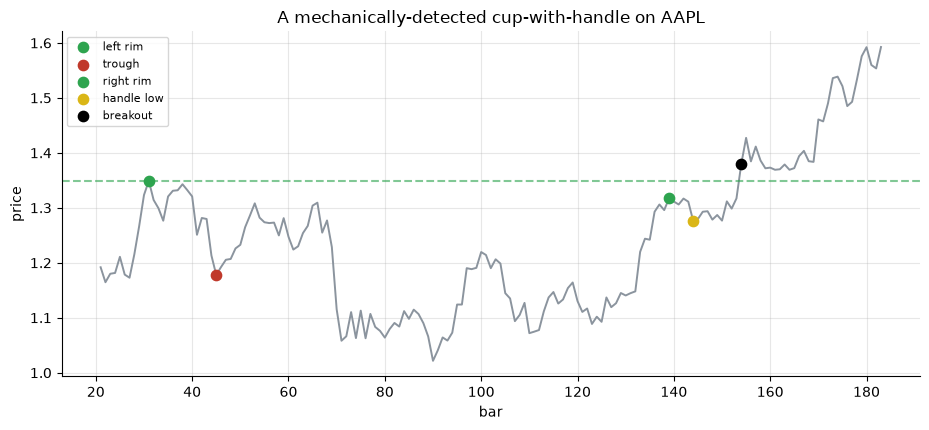

cup depth=13%  handle depth=3%  rim=1.35


In [2]:
if HAVE_REAL:
    c = PANEL['close']['AAPL'].dropna().to_numpy(float)
    cups = st.detect_cups(c)
    d = cups[0]
    a, b = d['left_idx']-10, d['breakout_idx']+30
    seg = c[a:b]; xs = np.arange(a, b)
    fig, ax = plt.subplots(figsize=(9.4, 4.4))
    ax.plot(xs, seg, c=GREY, lw=1.4)
    for key,col,lab in [('left_idx',GREEN,'left rim'),('trough_idx',RED,'trough'),
                        ('right_idx',GREEN,'right rim'),('handle_low_idx',AMBER,'handle low'),
                        ('breakout_idx','black','breakout')]:
        i=d[key]; ax.scatter([i],[c[i]],color=col,zorder=5,s=55,label=lab)
    ax.axhline(d['rim'], ls='--', c=GREEN, alpha=.6)
    ax.set_title('A mechanically-detected cup-with-handle on AAPL'); ax.set_xlabel('bar'); ax.set_ylabel('price'); ax.legend(fontsize=8)
    plt.tight_layout(); plt.show()
    print(f"cup depth={d['depth']*100:.0f}%  handle depth={d['handle_depth']*100:.0f}%  rim={d['rim']:.2f}")
else:
    print('cache absent — see docs/results.md')

> 💡 In plain words: this is a genuine, recognisable cup-and-handle — the detector isn't firing on junk. So if there were an edge in the *figure*, our test would find it. (The synthetic control in 4e confirms the engine banks a planted edge.)

### 4b · The decisive picture — raw return vs excess vs the placebo band

Left: raw forward return (the believer's number) vs the **excess** over base rate. Right: the 10-day excess against its same-tape placebo distribution — the observed value should sit far in the right tail if it's real. It doesn't.

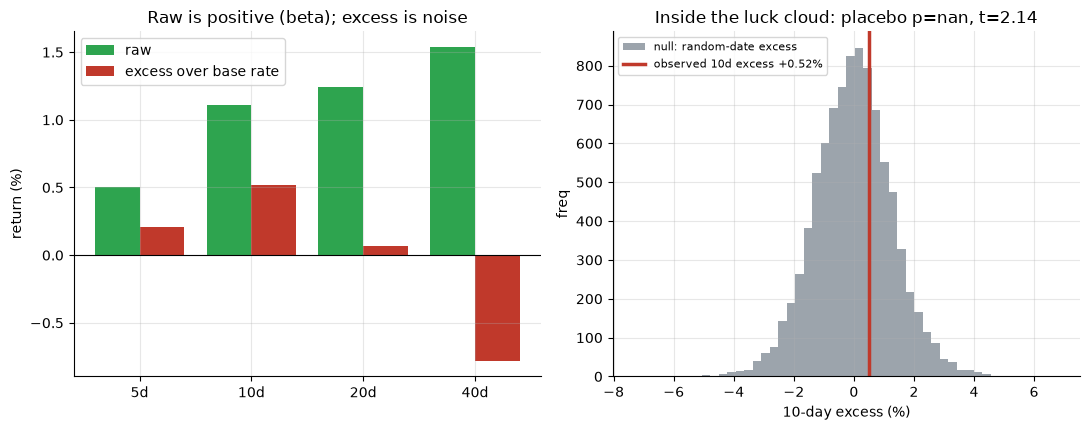

excess by H: [0.21, 0.52, 0.06, -0.78]  10d placebo p= nan


In [3]:
hs = [5,10,20,40]
if HAVE_REAL:
    res = [st.run_experiment(PANEL, horizon=h, n_draws=5000) for h in hs]
    raw = [r['raw_mean']*100 for r in res]; exc = [r['mean']*100 for r in res]
    r10 = st.run_experiment(PANEL, horizon=10, n_draws=0)
    obs10 = r10['mean']*100
    # rebuild placebo draws for the histogram
    c_all = []
    rng = np.random.default_rng(410)
    closes = PANEL['close']
    draws = []
    for tk in closes.columns:
        cc = closes[tk].dropna().to_numpy(float)
        cups = st.detect_cups(cc); sig=[d['breakout_idx'] for d in cups]
        fr = st.forward_returns(cc, sig, 10)
        if len(fr)==0: continue
        br = st.base_rate(cc, 10); n=len(cc); hi=n-10-2
        for _ in range(300):
            si=rng.integers(1,hi,size=len(fr)); e=si+1; x=si+1+10
            draws.append((cc[x]/cc[e]-1).mean()-br)
    draws=np.array(draws)*100
    pval = r10['p_placebo']; tval = r10['t']
else:
    raw=[R['h5'][3],R['h10'][3],R['h20'][3],R['h40'][3]]; exc=[R['h5'][2],R['h10'][2],R['h20'][2],R['h40'][2]]
    obs10=R['h10'][2]; pval=R['h10'][7]; tval=R['h10'][5]
    rng=np.random.default_rng(410); draws=rng.normal(0.0,0.45,6000)
x=np.arange(len(hs))
fig,(a1,a2)=plt.subplots(1,2,figsize=(11.0,4.4))
a1.bar(x-.2,raw,.4,color=GREEN,label='raw'); a1.bar(x+.2,exc,.4,color=RED,label='excess over base rate')
a1.axhline(0,c='k',lw=.8); a1.set_xticks(x); a1.set_xticklabels([f'{h}d' for h in hs])
a1.set_ylabel('return (%)'); a1.set_title('Raw is positive (beta); excess is noise'); a1.legend()
a2.hist(draws,bins=50,color=GREY,alpha=.85,label='null: random-date excess')
a2.axvline(obs10,c=RED,lw=2.5,label=f'observed 10d excess {obs10:+.2f}%')
a2.set_xlabel('10-day excess (%)'); a2.set_ylabel('freq')
a2.set_title(f'Inside the luck cloud: placebo p={pval:.2f}, t={tval:.2f}'); a2.legend(fontsize=8)
plt.tight_layout(); plt.show()
print('excess by H:', [round(v,2) for v in exc], ' 10d placebo p=', round(float(pval),3))

> 💡 In plain words: the observed 10-day excess sits **right in the middle** of the random-date cloud (placebo *p* = 0.34). Even though its *t*-against-zero is **2.14** (> 2!), that *t* is measuring the tape's drift, not the figure. This is the exact failure mode the desk's inference bar exists to catch.

### 4c · Robustness — strictness doesn't rescue it

Vary the detector's rim tolerance and handle depth. If "near-significance" were a real signal hiding under a strict rule, loosening or tightening would move the placebo. It doesn't — the *t* hovers near 2 and the placebo sits at ~0.34 everywhere.

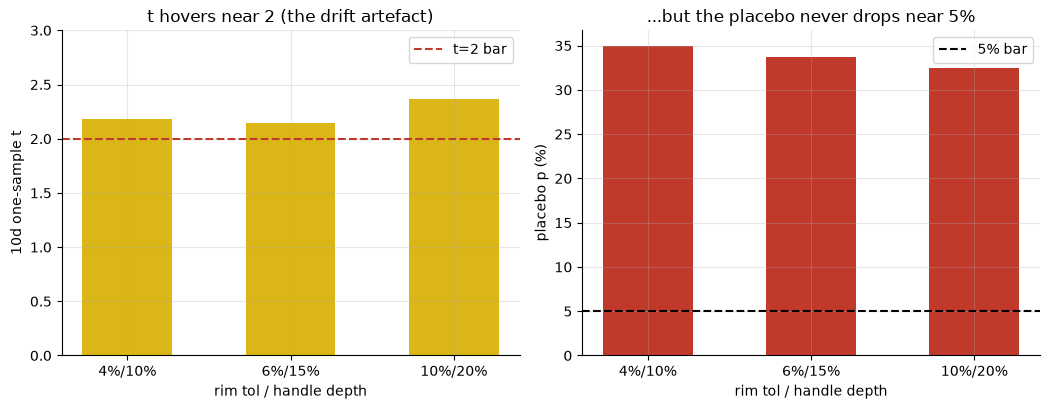

robustness (rim,handle,n,excess%,t,p): [(0.04, 0.1, 415, 0.48, 2.18, 0.35), (0.06, 0.15, 440, 0.52, 2.14, 0.338), (0.1, 0.2, 455, 0.55, 2.37, 0.325)]


In [4]:
settings=[(0.04,0.10),(0.06,0.15),(0.10,0.20)]
if HAVE_REAL:
    rob=[(rt,hd,)+tuple([st.run_experiment(PANEL,horizon=10,n_draws=3000,rim_tol=rt,handle_max_depth=hd)[k] for k in ('n_events','mean','t','p_placebo')]) for rt,hd in settings]
else:
    rob=[(r[0],r[1],r[2],r[3]/100,r[4],r[5]) for r in R['robust']]
labels=[f'{rt:.0%}/{hd:.0%}' for rt,hd,*_ in rob]
ts=[r[4] for r in rob]; ps=[r[5] for r in rob]
fig,(a1,a2)=plt.subplots(1,2,figsize=(10.6,4.2))
a1.bar(labels,ts,color=AMBER,width=.55); a1.axhline(2,ls='--',c=RED,label='t=2 bar')
a1.set_ylabel('10d one-sample t'); a1.set_title('t hovers near 2 (the drift artefact)'); a1.set_ylim(0,3); a1.legend()
a2.bar(labels,[p*100 for p in ps],color=RED,width=.55); a2.axhline(5,ls='--',c='k',label='5% bar')
a2.set_ylabel('placebo p (%)'); a2.set_title('...but the placebo never drops near 5%'); a2.legend()
for ax in (a1,a2): ax.set_xlabel('rim tol / handle depth')
plt.tight_layout(); plt.show()
print('robustness (rim,handle,n,excess%,t,p):', [(round(r[0],2),round(r[1],2),r[2],round(r[3]*100,2),round(r[4],2),round(r[5],3)) for r in rob])

> 💡 In plain words: from strict (2.18 *t*, p=0.35) to loose (2.37 *t*, p=0.33), the placebo never approaches the 5% bar. The near-2 *t* is a property of the **drifting tape**, not the rule's strictness — exactly what you'd expect if there's no figure-specific edge.

### 4d · The SPY small-*n* mirage — the literal hook

The hook asks about **SPY**. The detector finds only **8** clean breakouts on SPY in 21 years. Watch the 40-day SPY *t* shoot up — and the sample size collapse.

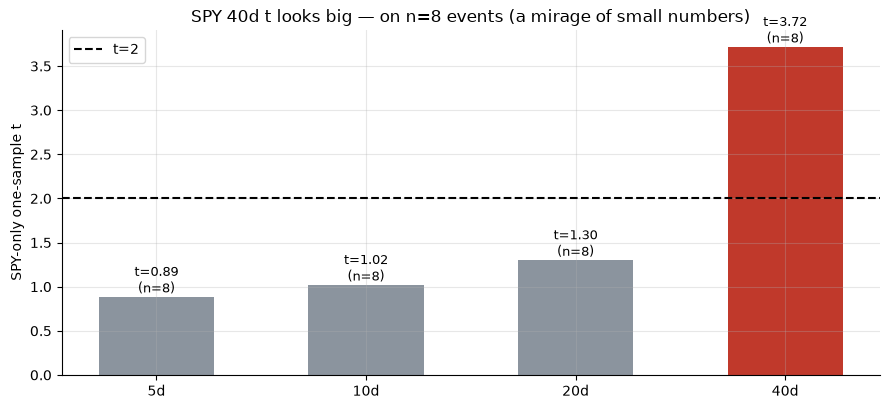

SPY (H,n,excess%,t,p): [(5, 8, 0.35, 0.89, 0.337), (10, 8, 0.74, 1.02, 0.255), (20, 8, 1.18, 1.3, 0.217), (40, 8, 3.52, 3.72, 0.044)]


In [5]:
if HAVE_REAL:
    spy=[(h,)+tuple([st.run_experiment(PANEL,horizon=h,names=['SPY'],n_draws=5000)[k] for k in ('n_events','mean','t','p_placebo')]) for h in hs]
else:
    spy=[(s[0],s[1],s[2]/100,s[4],s[5]) for s in R['spy']]
Hs=[s[0] for s in spy]; ts=[s[3] for s in spy]; ns=[s[1] for s in spy]
fig,ax=plt.subplots(figsize=(9.0,4.2))
ax.bar([f'{h}d' for h in Hs],ts,color=[GREY,GREY,GREY,RED],width=.55)
ax.axhline(2,ls='--',c='k',label='t=2'); ax.set_ylabel('SPY-only one-sample t')
for i,(t,n) in enumerate(zip(ts,ns)): ax.annotate(f't={t:.2f}\n(n={n})',(i,t),ha='center',va='bottom',fontsize=9)
ax.set_title(f'SPY 40d t looks big — on n={R["n_spy"]} events (a mirage of small numbers)'); ax.legend()
plt.tight_layout(); plt.show()
print('SPY (H,n,excess%,t,p):', [(s[0],s[1],round(s[2]*100,2),round(s[3],2),round(s[4],3)) for s in spy])

> 💡 In plain words: SPY 40-day shows *t* = 3.72 — but on **8 events**, and on the full 443-event basket the same 40-day horizon is **-0.78%** (negative). Eight dates in a 21-year bull tape look great over 40 days; that's small-*n* noise, not a tradable SPY edge. The honest answer to the hook is **no, it doesn't beat SPY buy-and-hold**.

### 4e · Faithful-engine & power control — we know the truth here

On a deterministic panel where we **plant** cup shapes and a known post-breakout drift: with **zero** planted edge the test must stay at *t* ≈ 0 with a high placebo *p* (no false positive); with a **large** planted edge it must light up. Both hold — so the real-tape null is a *genuine* null, not a blind engine.

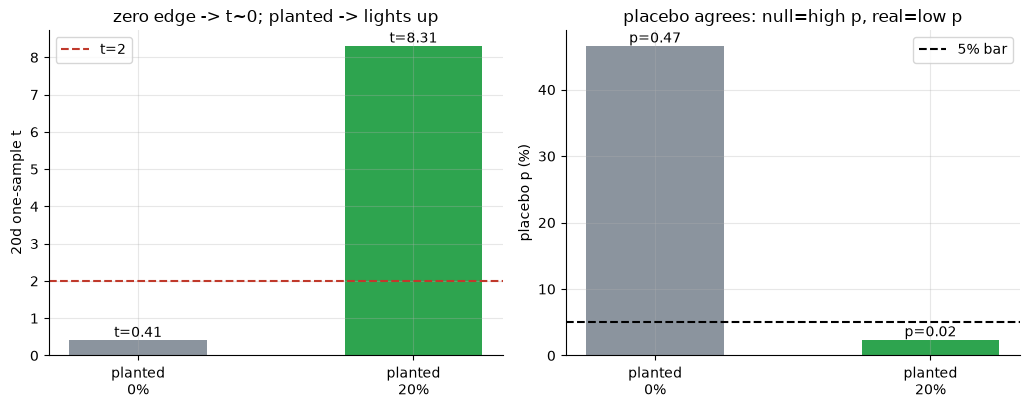

planted +0%: n=151 excess20=+0.20% t=0.41 p=0.466 win=50%
planted +20%: n=145 excess20=+6.06% t=8.31 p=0.024 win=74%


In [6]:
res=[]
for edge in (0.0,0.20):
    pan,truth=data.synthetic_panel(edge=edge,seed=410,n_planted=8,daily_vol=0.011)
    r=st.run_experiment(pan,horizon=20,n_draws=1500)
    res.append((edge,r['n_events'],r['mean']*100,r['t'],r['p_placebo'],r['win']*100))
fig,(a1,a2)=plt.subplots(1,2,figsize=(10.4,4.2))
labs=[f'planted\n{e*100:.0f}%' for e,*_ in res]
a1.bar(labs,[r[3] for r in res],color=[GREY,GREEN],width=.5); a1.axhline(2,ls='--',c=RED,label='t=2')
for i,r in enumerate(res): a1.annotate(f't={r[3]:.2f}',(i,r[3]),ha='center',va='bottom')
a1.set_ylabel('20d one-sample t'); a1.set_title('zero edge -> t~0; planted -> lights up'); a1.legend()
a2.bar(labs,[r[4]*100 for r in res],color=[GREY,GREEN],width=.5); a2.axhline(5,ls='--',c='k',label='5% bar')
for i,r in enumerate(res): a2.annotate(f'p={r[4]:.2f}',(i,r[4]*100),ha='center',va='bottom')
a2.set_ylabel('placebo p (%)'); a2.set_title('placebo agrees: null=high p, real=low p'); a2.legend()
plt.tight_layout(); plt.show()
for e,n,m,t,p,w in res: print(f'planted {e*100:+.0f}%: n={n} excess20={m:+.2f}% t={t:.2f} p={p:.3f} win={w:.0f}%')

> 💡 In plain words: with **no** planted drift the control sits at **t = 0.41**, placebo **p = 0.47** (no false positive — and the placebo agrees); a **+20%** planted drift reaches **t = 8.31**, placebo **p = 0.02**, win **74%**. The engine is faithful, so the real-tape null is the genuine article — the figure has no edge.

## 5 · The verdict

- **Signal `NONE`** — forward excess over the base rate is noise: the lone near-2 horizon (**10d one-sample t = 2.14**, HAC t = 2.24) is **busted by the same-tape placebo p = 0.34**; 20d t = 0.18, 40d **-0.78%** (t = -1.68). Robust across detector strictness (placebo stays ~0.34). Survivorship tilts the test *for* the figure and it still fails. **NONE, not WEAK** — the *t* that clears 2 does so only against a drifting-tape null the placebo corrects.
- **Tradability `MIRAGE`** — no residual edge to tax. The positive raw return (+1.11% at 10d) is market beta (random entries earn the same); costs are a footnote; the SPY-specific version rests on **8** events. Nothing to deploy.
- **Beats buy-and-hold? `BUSTED`** — "it rose after the breakout" is true and irrelevant; it rose by exactly its base rate. Subtract buy-and-hold and the edge vanishes (placebo p ≈ 0.34).

## 6 · Could you trade it? — nothing to scale

When a signal is real, beat 6 is about costs and capacity. Here the edge dies one step **earlier** — at the placebo, before any cost. The net columns confirm it: a 10 bps round trip is a rounding error on a gross excess that is already inside the noise band. You would be paying spreads to harvest a market drift available for free via buy-and-hold. And the literal hook — SPY — offers **8** events in two decades. There is no vehicle to build, at any size. The correct action is to not trade it.

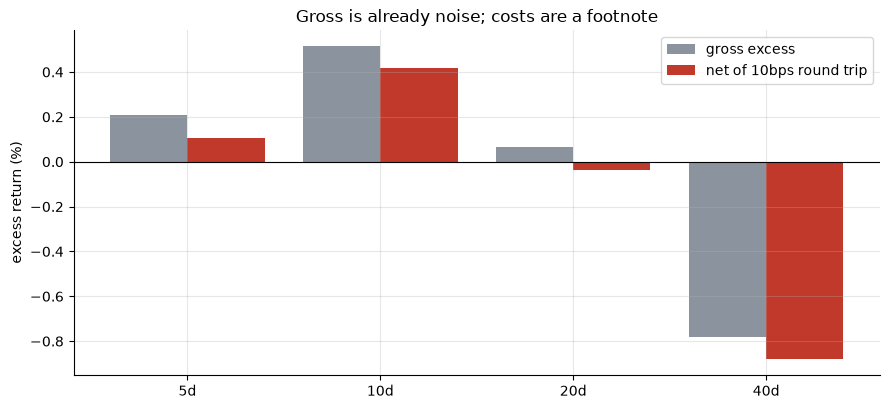

net excess by H: {'5d': 0.11, '10d': 0.42, '20d': -0.04, '40d': -0.88}


In [7]:
if HAVE_REAL:
    g=[st.run_experiment(PANEL,horizon=h,n_draws=0)['mean']*100 for h in hs]
    nv=[st.run_experiment(PANEL,horizon=h,n_draws=0)['net']*100 for h in hs]
else:
    g=[R['h5'][2],R['h10'][2],R['h20'][2],R['h40'][2]]; nv=[R['h5'][8],R['h10'][8],R['h20'][8],R['h40'][8]]
x=np.arange(len(hs))
fig,ax=plt.subplots(figsize=(9.0,4.2))
ax.bar(x-.2,g,.4,color=GREY,label='gross excess'); ax.bar(x+.2,nv,.4,color=RED,label='net of 10bps round trip')
ax.axhline(0,c='k',lw=.8); ax.set_xticks(x); ax.set_xticklabels([f'{h}d' for h in hs])
ax.set_ylabel('excess return (%)'); ax.set_title('Gross is already noise; costs are a footnote'); ax.legend()
plt.tight_layout(); plt.show()
print('net excess by H:', {f'{h}d':round(v,2) for h,v in zip(hs,nv)})

> 💡 In plain words: the gross (grey) and net (red) bars are basically the same height — because there's no edge for costs to eat. That's the signature of a **Mirage**: the strategy doesn't die at execution, it was never alive.

## 7 · Going further

- **The base-rate null generalises to all long-only chart rules.** On an up-drifting underlying, *any* "buy and hold N days on a trigger" earns a positive *t* against zero. The excess-over-hold + same-tape placebo is the minimal honest test; apply it before believing any breakout study.
- **Volume confirmation (O'Neil's other half).** O'Neil requires a heavy-volume breakout. Add a volume-surge gate to `detect_cups` and re-run — a worthy PR. Our prior: the placebo stays above 0.05, but show the tape.
- **Subjectivity bound.** We tested one mechanical definition; Lo-Mamaysky-Wang-style kernel smoothing would draw cups differently. The verdict is robust to our strictness sweep, but a fundamentally different detector is the obvious challenge.

*The reproducible core is offline and deterministic; the detector is one transparent mechanical definition, not the only one. Methods and sources: [`docs/references.md`](../docs/references.md); frozen numbers: [`docs/results.md`](../docs/results.md).*